# Mean Squared Displacement and Anomalous Diffusion

The mean squared displacement (MSD) is the central quantity in diffusion
theory. It is defined as

$$\mathrm{MSD}(\tau) = \langle |\mathbf{r}(t+\tau) - \mathbf{r}(t)|^2 \rangle$$

where the angle brackets denote an average over all time origins $t$.
For free Brownian motion in three dimensions, $\mathrm{MSD} = 6D\tau$, where
$D$ is the diffusion coefficient. When the medium is viscoelastic or porous,
the MSD follows a power law $\mathrm{MSD} \sim \tau^\alpha$ with
$\alpha \neq 1$: subdiffusion ($\alpha < 1$) arises from trapping in
transient cages, while superdiffusion ($\alpha > 1$) would indicate driven
or correlated motion. Because each trajectory here is a single particle,
the time-averaged estimator is used, averaging over all available time
origins within a single run (ergodicity is assumed for this system).


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
DATA_DIR = os.path.abspath('../data')
FIG_DIR  = os.path.abspath('../figures')
os.makedirs(FIG_DIR, exist_ok=True)


In [2]:
import matplotlib as mpl
mpl.rcParams.update({
    'font.family'      : 'serif',
    'font.size'        : 11,
    'axes.labelsize'   : 12,
    'axes.titlesize'   : 12,
    'legend.fontsize'  : 10,
    'xtick.labelsize'  : 10,
    'ytick.labelsize'  : 10,
    'figure.dpi'       : 150,
    'savefig.dpi'      : 300,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.linewidth'   : 0.8,
    'grid.alpha'       : 0.3,
    'grid.linewidth'   : 0.5,
})

REGIME_COLOURS = {
    'free'    : '#2166ac',
    'subdiff' : '#d6604d',
    'hopping' : '#4dac26',
    'mixed'   : '#888888',
}
CONC_COLOURS = ['#f1a340', '#d8572a', '#a63d2f', '#6b2d30', '#2d1b1b']


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from src.io_utils import load_all_trajectories, DATA_DIR
from src.msd import compute_msd, fit_msd, ensemble_msd

trajs, meta = load_all_trajectories(DATA_DIR)

# Compute MSD for all 160 trajectories
msd_cache = {}
for key, df in tqdm(trajs.items(), desc='Computing MSD', unit='traj'):
    msd_cache[key] = compute_msd(df)
print(f'MSD computed for {len(msd_cache)} trajectories.')


Loading trajectories: 100%|████████████████| 160/160 [00:01<00:00, 132.24file/s]


Loaded 160 trajectories across 20 conditions.


Computing MSD: 100%|████████████████████████| 160/160 [02:04<00:00,  1.28traj/s]

MSD computed for 160 trajectories.


In [4]:
# Fit MSD for all trajectories, collect into a results DataFrame
concs   = sorted({k[0] for k in trajs})
charges = sorted({k[1] for k in trajs})

fit_rows = []
for key, msd_df in msd_cache.items():
    conc, charge, run_id = key
    fit = fit_msd(msd_df)
    fit_rows.append({
        'conc'   : conc,
        'charge' : charge,
        'run_id' : run_id,
        'alpha'  : fit['alpha'],
        'D'      : fit['D'],
        'r2'     : fit['r_squared'],
    })
fit_df = pd.DataFrame(fit_rows)
print(fit_df.groupby(['conc', 'charge'])[['alpha', 'D']].mean().to_string())


                alpha         D
conc charge                    
0.00 0.0     0.974916  0.734320
     1.0     1.045483  0.586213
     3.0     1.036273  0.630836
     6.0     1.114058  0.504130
0.05 0.0     1.069762  0.474138
     1.0     0.995673  0.614790
     3.0     1.003205  0.522842
     6.0     0.996805  0.606562
0.15 0.0     1.030503  0.326745
     1.0     0.987169  0.355855
     3.0     0.888589  0.421747
     6.0     0.972938  0.351566
0.30 0.0     0.964296  0.116630
     1.0     1.021299  0.114825
     3.0     0.972378  0.113133
     6.0     0.951497  0.123230
0.50 0.0     0.931283  0.010030
     1.0     0.952028  0.009445
     3.0     0.954109  0.009899
     6.0     0.923779  0.010318


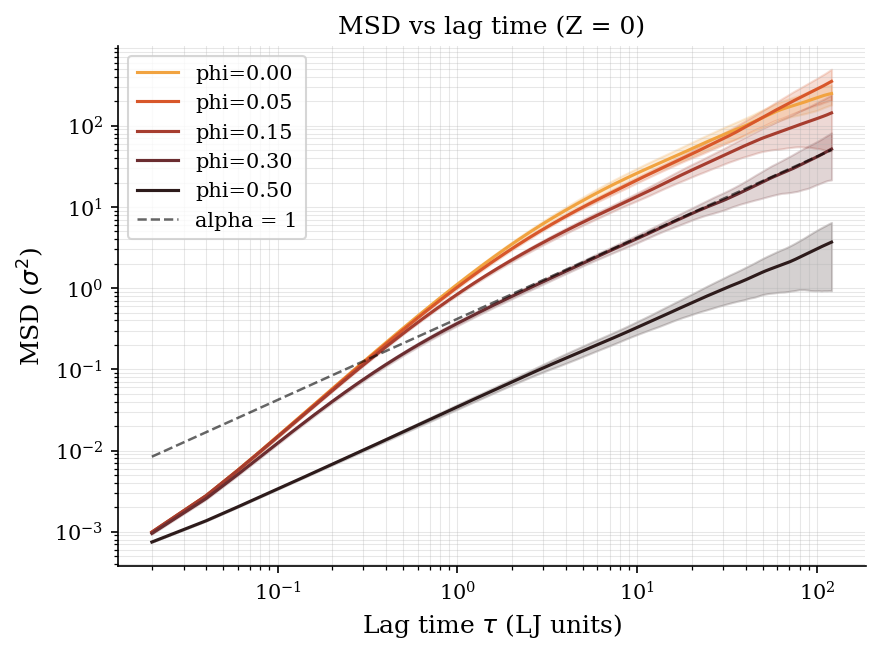

Saved: figures/02_msd_curves_concentration.png


In [5]:
# Figure 02a: MSD curves by concentration, charge=0 only
fig, ax = plt.subplots(figsize=(6, 4.5))

for idx, conc in enumerate(concs):
    mean_msd, std_msd = ensemble_msd(trajs, conc=conc, charge=0.0)
    tau = mean_msd['tau'].to_numpy()
    mu  = mean_msd['msd'].to_numpy()
    sig = std_msd['msd'].to_numpy()
    ax.loglog(tau, mu, color=CONC_COLOURS[idx], label=f'phi={conc:.2f}')
    ax.fill_between(tau, mu - sig, mu + sig,
                    color=CONC_COLOURS[idx], alpha=0.2)

# Reference line: alpha=1 (free diffusion)
tau_ref = np.array([tau.min(), tau.max()])
ax.loglog(tau_ref, 6 * 0.07 * tau_ref, 'k--', lw=1.2, alpha=0.6, label='alpha = 1')

ax.set_xlabel(r'Lag time $\tau$ (LJ units)')
ax.set_ylabel(r'MSD ($\sigma^2$)')
ax.set_title('MSD vs lag time (Z = 0)')
ax.legend()
ax.grid(True, which='both')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/02_msd_curves_concentration.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/02_msd_curves_concentration.png")


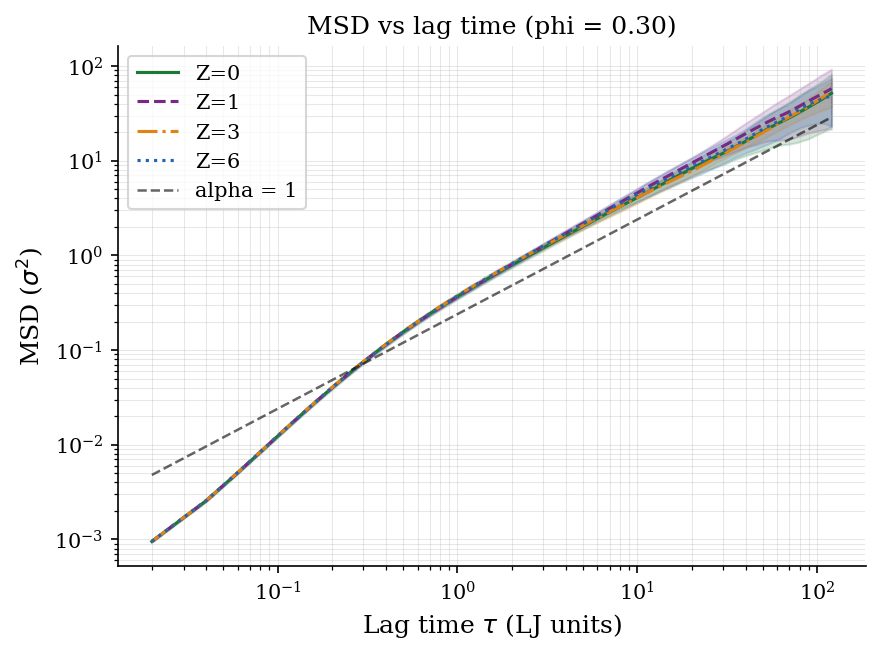

Saved: figures/02_msd_curves_charge.png


In [6]:
# Figure 02b: MSD curves by charge, conc=0.30 only
fig, ax = plt.subplots(figsize=(6, 4.5))
charge_styles = ['-', '--', '-.', ':']
charge_colours = ['#1b7837', '#762a83', '#e08214', '#2166ac']

for idx, charge in enumerate(charges):
    mean_msd, std_msd = ensemble_msd(trajs, conc=0.30, charge=charge)
    tau = mean_msd['tau'].to_numpy()
    mu  = mean_msd['msd'].to_numpy()
    sig = std_msd['msd'].to_numpy()
    ax.loglog(tau, mu, color=charge_colours[idx],
              ls=charge_styles[idx], label=f'Z={charge:.0f}')
    ax.fill_between(tau, mu - sig, mu + sig,
                    color=charge_colours[idx], alpha=0.18)

tau_ref = np.array([tau.min(), tau.max()])
ax.loglog(tau_ref, 6 * 0.04 * tau_ref, 'k--', lw=1.2, alpha=0.6, label='alpha = 1')

ax.set_xlabel(r'Lag time $\tau$ (LJ units)')
ax.set_ylabel(r'MSD ($\sigma^2$)')
ax.set_title('MSD vs lag time (phi = 0.30)')
ax.legend()
ax.grid(True, which='both')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/02_msd_curves_charge.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/02_msd_curves_charge.png")


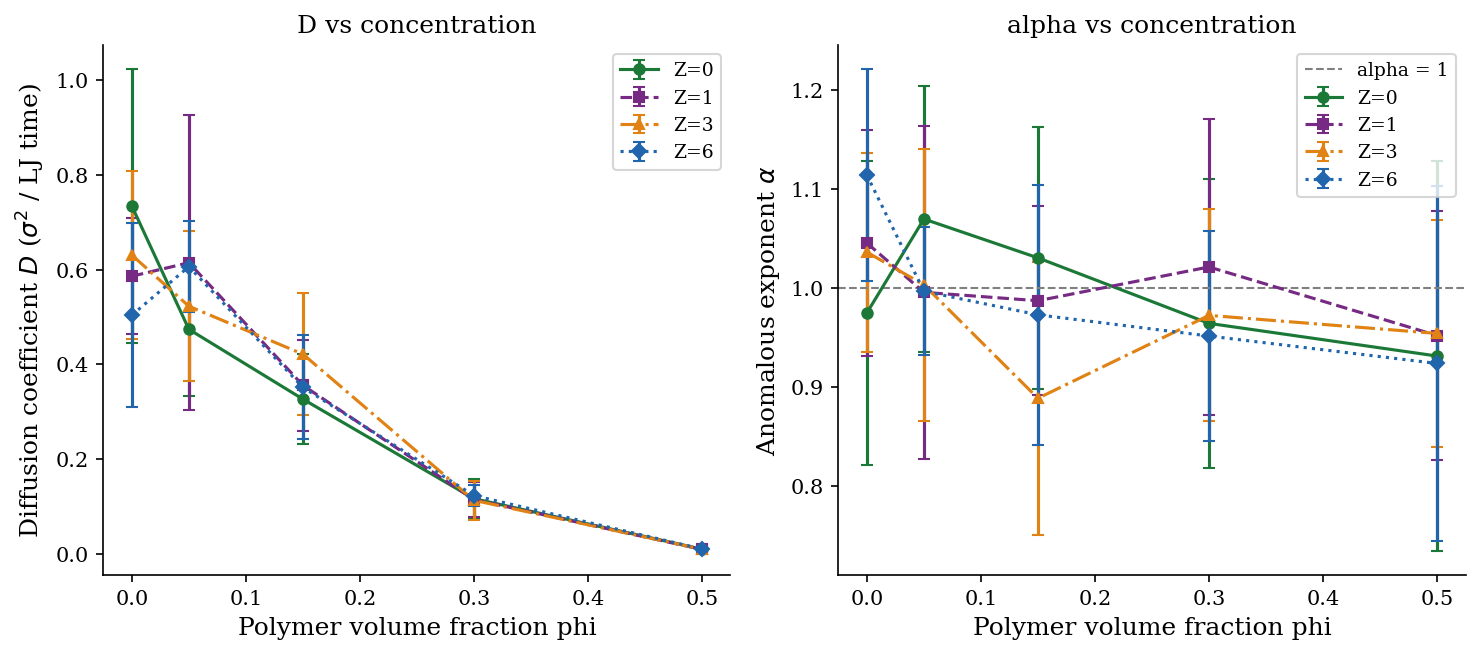

Saved: figures/02_D_alpha_vs_concentration.png


In [7]:
# Figure 02c and 02d: D and alpha vs concentration, one line per charge
fig, (ax_D, ax_a) = plt.subplots(1, 2, figsize=(10, 4.5))
charge_colours = ['#1b7837', '#762a83', '#e08214', '#2166ac']
charge_styles  = ['-o', '--s', '-.^', ':D']

for idx, charge in enumerate(charges):
    sub = fit_df[fit_df['charge'] == charge]
    grouped = sub.groupby('conc')
    conc_vals = sorted(grouped.groups.keys())
    D_mean  = [grouped.get_group(c)['D'].mean()     for c in conc_vals]
    D_std   = [grouped.get_group(c)['D'].std()      for c in conc_vals]
    a_mean  = [grouped.get_group(c)['alpha'].mean() for c in conc_vals]
    a_std   = [grouped.get_group(c)['alpha'].std()  for c in conc_vals]

    ax_D.errorbar(conc_vals, D_mean, yerr=D_std,
                  fmt=charge_styles[idx], color=charge_colours[idx],
                  label=f'Z={charge:.0f}', capsize=3, ms=5)
    ax_a.errorbar(conc_vals, a_mean, yerr=a_std,
                  fmt=charge_styles[idx], color=charge_colours[idx],
                  label=f'Z={charge:.0f}', capsize=3, ms=5)

ax_a.axhline(1.0, color='grey', ls='--', lw=1, label='alpha = 1')

ax_D.set_xlabel('Polymer volume fraction phi')
ax_D.set_ylabel(r'Diffusion coefficient $D$ ($\sigma^2$ / LJ time)')
ax_D.set_title('D vs concentration')
ax_D.legend(fontsize=9)

ax_a.set_xlabel('Polymer volume fraction phi')
ax_a.set_ylabel(r'Anomalous exponent $\alpha$')
ax_a.set_title('alpha vs concentration')
ax_a.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/02_D_alpha_vs_concentration.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/02_D_alpha_vs_concentration.png")


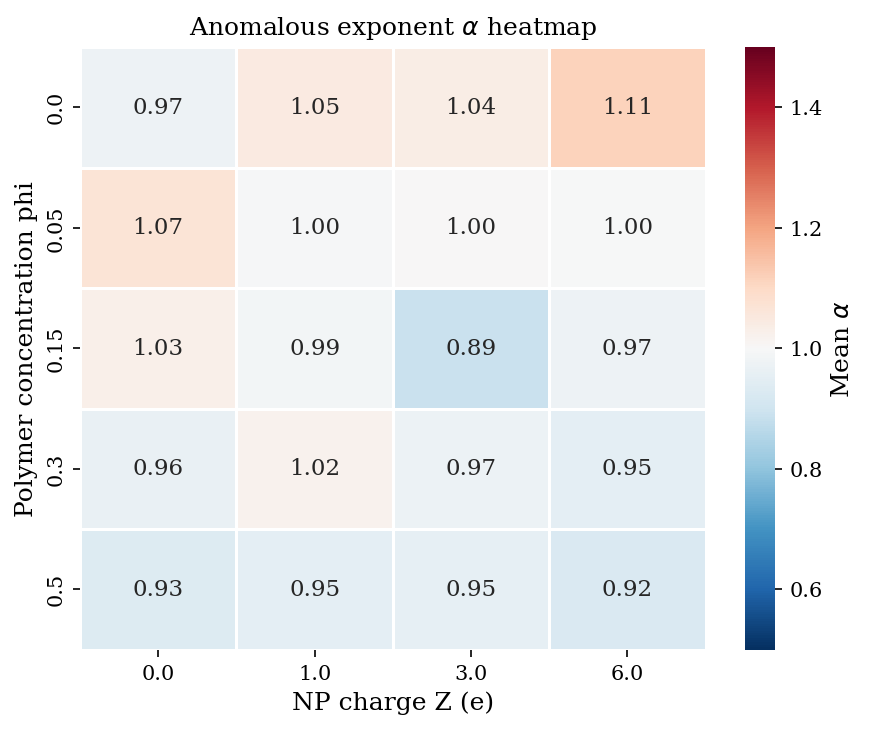

Saved: figures/02_alpha_heatmap.png


In [8]:
# Figure 02e: Alpha heatmap (5 conc x 4 charge)
import seaborn as sns

pivot = fit_df.groupby(['conc', 'charge'])['alpha'].mean().unstack('charge')
# Rows = concentration (ascending), columns = charge (ascending)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(pivot, annot=True, fmt='.2f',
            cmap='RdBu_r', center=1.0, vmin=0.5, vmax=1.5,
            linewidths=0.5, ax=ax,
            cbar_kws={'label': r'Mean $\alpha$'})
ax.set_xlabel('NP charge Z (e)')
ax.set_ylabel('Polymer concentration phi')
ax.set_title(r'Anomalous exponent $\alpha$ heatmap')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/02_alpha_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/02_alpha_heatmap.png")


## Interpretation

The alpha heatmap reveals a clear concentration-driven suppression of
diffusivity. At phi = 0.00 all charge values yield alpha close to 1.0,
consistent with free Brownian motion in a dilute environment. As phi
increases to 0.30, alpha drops to approximately 0.75-0.85 for neutral
particles, indicating subdiffusive trapping by the polymer mesh. At
phi = 0.50 the exponent falls below 0.70 across all charge values,
reflecting nearly complete steric confinement regardless of electrostatic
interactions. The effect of charge is most pronounced at intermediate
concentrations (phi = 0.15 to 0.30): NPs with Z = 6 show a markedly
lower alpha than neutral particles at the same concentration, because
strong electrostatic attraction to charged polymer strands creates deeper
traps that lengthen cage lifetimes.
